Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Loaded the loan prediction dataset for anaysis

In [3]:
df = pd.read_csv(r"C:\Users\KEERTHI SRI S\OneDrive\Desktop\AI_Data_Journey\2Months_of_ML\train_u6lujuX_CVtuZ9i.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Handling missing value and remove the unnecessary columns

In [4]:
df.drop('Loan_ID', axis=1, inplace=True)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

Convert categorical variables into numerical format

In [5]:
df = pd.get_dummies(df, drop_first=True)

Split the dataset into training and testing set

In [6]:
X = df.drop('Loan_Status_Y', axis=1)
y = df['Loan_Status_Y']
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state =42, stratify=y)

Trained random forest model on the training data 

In [7]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

Compared training and testing accuracy to identify underfitting or overfitting

In [19]:
train_score = model.score(X_train,y_train)
test_score = model.score(X_test, y_test)
print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Train Accuracy: 1.0
Test Accuracy: 0.8373983739837398


Evaluated model performance using multiple data splits

In [11]:
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.79674797 0.74796748 0.76422764 0.80487805 0.81967213]
Average CV score: 0.7866986538717847


Defined parameters to tune the model for better performance

In [13]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, 8]
}

Used GridSearchCV to find the best model parameters

In [14]:
grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [4, 6, 8], 'n_estimators': [50, 100]})

Displayed the optimal parameters found by GridSearch

In [15]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 6, 'n_estimators': 50}
Best CV Score: 0.8004122861265719


Evaluated the final model performance using accuracy score

In [16]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.8455284552845529


Visualized model performance using confusion matrix

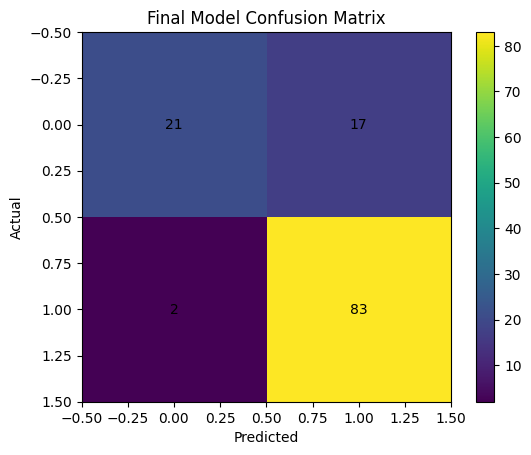

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Final Model Confusion Matrix")
plt.colorbar()
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()